In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [63]:
data = pd.read_csv("Data.csv")
us_data = data[(data['Series Name'] == "Current health expenditure per capita (current US$)")&(data['Country Name'] == 'United States')]

In [64]:
us_data

,Series Name,Country Name,2000,2001,2002,2003,2004,2005,2006,2007,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
2810,Current health expenditure per capita (current...,United States,4548.554688,4901.675293,5327.937012,5732.243652,6071.844238,6428.602051,6802.475098,7153.731445,...,8796.182617,9200.858398,9536.206055,9822.378906,10182.25586,10546.01367,11672.77051,11999.09082,12434.43359,


In [65]:
us_data_capita = us_data.iloc[:, 2:]
us_data_capita.index = ["Health Expenditure per Capita"]

In [66]:
us_data_capita.head()

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Health Expenditure per Capita,4548.554688,4901.675293,5327.937012,5732.243652,6071.844238,6428.602051,6802.475098,7153.731445,7364.938477,7614.824219,...,8796.182617,9200.858398,9536.206055,9822.378906,10182.25586,10546.01367,11672.77051,11999.09082,12434.43359,


In [67]:
print(us_data_capita.dtypes)

2000    object
2001    object
2002    object
2003    object
2004    object
2005    object
2006    object
2007    object
2008    object
2009    object
2010    object
2011    object
2012    object
2013    object
2014    object
2015    object
2016    object
2017    object
2018    object
2019    object
2020    object
2021    object
2022    object
2023    object
dtype: object


In [68]:
#us_data_capita = us_data.iloc[:, 2:]
#us_data_capita.index = ["Health Expenditure per Capita"]

In [69]:
#us_data_capita.head()

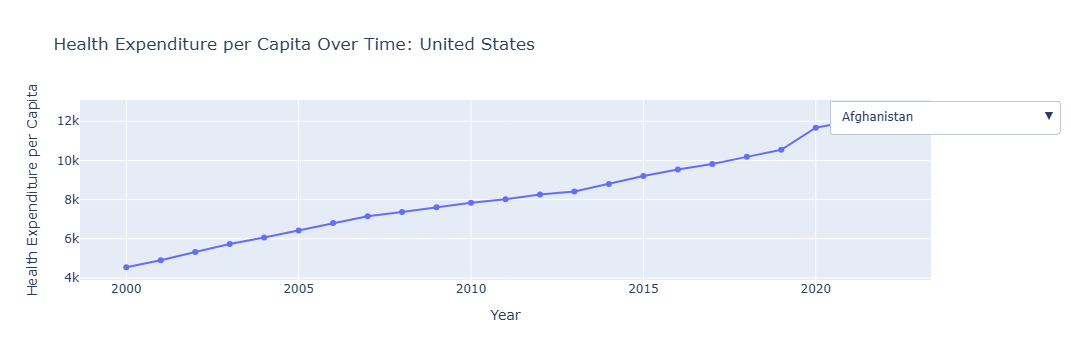

In [75]:
# creating a seperate df for just health expenditures
health_df = data[data["Series Name"] == "Current health expenditure per capita (current US$)"].copy()
health_long = health_df.melt(
    id_vars=["Country Name", "Series Name"],
    var_name="Year",
    value_name="Health Expenditure per Capita"
)

# filtering the year and health expenditures
health_long["Year"] = pd.to_numeric(health_long["Year"], errors="coerce")
health_long["Health Expenditure per Capita"] = pd.to_numeric(
    health_long["Health Expenditure per Capita"], errors="coerce"
)
health_long = health_long.dropna(subset=["Year", "Health Expenditure per Capita"])

countries = sorted(health_long["Country Name"].unique()) #sorting by the country name

fig = go.Figure()

for i, country in enumerate(countries):
    country_data = health_long[health_long["Country Name"] == country]
    fig.add_trace(
        go.Scatter(
            x=country_data["Year"],
            y=country_data["Health Expenditure per Capita"],
            mode="lines+markers",
            name=country,
            visible=(country == "United States")
        )
    )

buttons = []
for country in countries:
    visible = [c == country for c in countries]
    buttons.append(
        dict(
            label=country,
            method="update",
            args=[
                {"visible": visible},
                {"title.text": f"Health Expenditure per Capita Over Time: {country}"}
            ]
        )
    )

fig.update_layout(
    title="Health Expenditure per Capita Over Time: United States",
    xaxis_title="Year",
    yaxis_title="Health Expenditure per Capita",
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=1.15,
            y=1
        )
    ]
)

fig.show()

In [71]:
data.head()

,Series Name,Country Name,2000,2001,2002,2003,2004,2005,2006,2007,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,"Adolescent fertility rate (births per 1,000 wo...",Afghanistan,154.31,152.471,150.161,143.75,136.93,130.838,121.635,117.754,...,84.069,81.043,78.13,75.3,73.021,70.967,68.877,66.599,65.339,64.068
1,"Adolescent fertility rate (births per 1,000 wo...",Albania,14.743,8.811,13.511,15.889,17.662,18.216,16.517,15.882,...,21.767,20.656,18.518,16.778,15.456,14.949,14.004,13.002,12.827,12.789
2,"Adolescent fertility rate (births per 1,000 wo...",Algeria,8.658,8.065,7.74,7.727,7.789,7.87,8.403,8.795,...,10.196,10.294,10.5,9.978,9.495,10.328,9.901,9.343,8.977,8.698
3,"Adolescent fertility rate (births per 1,000 wo...",American Samoa,48.376,46.153,44.466,42.685,41.905,38.191,35.852,33.607,...,43.059,42.174,39.45,37.274,35.427,34.278,34.149,34.214,34.104,34.181
4,"Adolescent fertility rate (births per 1,000 wo...",Andorra,9.075,9.84,9.384,8.335,8.712,9.064,9.383,9.034,...,4.947,4.936,4.576,4.326,3.832,3.526,3.119,3.5,3.527,3.48


In [72]:
data["Series Name"].unique()

array(['Adolescent fertility rate (births per 1,000 women ages 15-19)',
       'Adults (ages 15+) and children (ages 0-14) newly infected with HIV',
       'Adults (ages 15-49) newly infected with HIV',
       'Age dependency ratio (% of working-age population)',
       'Age dependency ratio, old (% of working-age population)',
       'Age dependency ratio, young (% of working-age population)',
       'Antiretroviral therapy coverage (% of people living with HIV)',
       'Birth rate, crude (per 1,000 people)',
       'Births attended by skilled health staff (% of total)',
       'Children (0-14) living with HIV',
       'Children (ages 0-14) newly infected with HIV',
       'Current health expenditure (% of GDP)',
       'Current health expenditure per capita (current US$)',
       'Current health expenditure per capita, PPP (current international $)',
       'Death rate, crude (per 1,000 people)',
       'Domestic general government health expenditure (% of current health expenditure

In [73]:
import altair as alt

# select year choice for the data 
year = "2021"
health_choice = "Physicians (per 1,000 people)"
mortality = "Mortality rate, under-5 (per 1,000 live births)"
pop = "Population growth (annual %)"

needed = data.loc[
    data["Series Name"].isin([health_choice, mortality, pop]),
    ["Country Name", "Series Name", year]
].copy()

needed[year] = pd.to_numeric(needed[year], errors="coerce")
wide = needed.pivot_table(
    index="Country Name",
    columns="Series Name",
    values=year,
    aggfunc="first"
).reset_index()

# keep only complete case
wide = wide.dropna(subset=[health_choice, mortality, pop])

# create the altair plot
chart1 = alt.Chart(wide).mark_circle(opacity=0.7).encode(
    x=alt.X(health_choice, title=f"{health_choice} ({year})"),
    y=alt.Y(mortality, title=f"{mortality} ({year})"),
    size=alt.Size(
        pop,
        title=f"{pop} ({year})",
        scale=alt.Scale(zero=False)
    ),
    color=alt.Color(
        pop,
        title=f"{pop} ({year})",
        scale=alt.Scale(scheme="viridis")
    ),
    tooltip=[
        alt.Tooltip("Country Name", title="Country"),
        alt.Tooltip(health_choice, format=".3f"),
        alt.Tooltip(mortality, format=".3f"),
        alt.Tooltip(pop, format=".2f")
    ]
)

line = alt.Chart(wide).transform_regression(
    health_choice, mortality, method="poly"
).mark_line(color="blue", size=2).encode(
    x=health_choice,
    y=mortality
)
chart = (chart1 + line).properties(
    width=650,
    height=450,
    title=f"Health resources vs mortality, sized by population growth ({year})"
).interactive()

chart.save("alt_scatterplot.html")
chart

alt.LayerChart(...)